In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import warnings
warnings.simplefilter("ignore")

pd.set_option('display.precision', 2)

def smart_formatter(x, pos):
    if x == 0.5:
        return "0.5"
    elif x < 1:
        return f"{x:.2f}"
    else:
        return f"{int(x)}"

smart_fmt = FuncFormatter(smart_formatter)

def highlight_col_min(s):
    is_min = s == s.min()
    return ['background-color: lightgreen' if v else '' for v in is_min]


def load_scampi(df_all):
    dir_path = "../tests/results/scampi_ablation_new/"
    
    if os.path.isdir(dir_path):
        print(f"Reading from{dir_path}")
        json_files = glob.glob(os.path.join(dir_path, "*.json"))
        dfs = [pd.read_json(file) for file in json_files]
        
        for key, df in zip(json_files, dfs):
            filename = os.path.basename(key)
            end = filename.find("pyattimo")
            df["dataset"] = filename[14:end-4]
            
            gb = filename.split('_')[-1].split()[0]

            if int(gb) <= 128:
                df["memory"] = gb  + " GB"
                df["version"] = "SCAMPI (" + gb + " GB)"
                df["backend"] = "SCAMPI (" + gb + " GB)"
            else:
                val = str(int(gb)/1024)
                df["memory"] = val + " GB"
                df["version"] = "SCAMPI (" + val + " GB)"
                df["backend"] = "SCAMPI (" + val + " GB)"

            df["extent@k"] = np.sqrt(df["extent"].apply(lambda l : l[-1]))
            df["lower_bound"] = df["lower_bound"].apply(lambda l : l[-1])
            df["extent@k - lower_bound"] = df["extent@k"] - df["lower_bound"]

        df_config = pd.concat(dfs, ignore_index=True)
        
        df_all = pd.concat([df_all, df_config], ignore_index=True)
    else:
        print("Does not exist")

    return df_all

df_all = pd.DataFrame()
df_all = load_scampi(df_all)

custom_order = ["0.25 GB", "0.5 GB", "1 GB", "2 GB", "4 GB", "8 GB", "16 GB", "32 GB", "64 GB", "128 GB"]
df_all = df_all[df_all.memory.isin(custom_order)].copy()

display(df_all.backend.unique())
display(df_all.dataset.unique())

Reading from../tests/results/scampi_ablation_new/


array(['SCAMPI (4 GB)', 'SCAMPI (1 GB)', 'SCAMPI (128 GB)',
       'SCAMPI (8 GB)', 'SCAMPI (0.25 GB)', 'SCAMPI (64 GB)',
       'SCAMPI (2 GB)', 'SCAMPI (16 GB)', 'SCAMPI (32 GB)',
       'SCAMPI (0.5 GB)'], dtype=object)

array(['Lab_FD_061014', 'MGHSleepElectromyography', 'FingerFlexionECoG',
       'SynchrophasorEventsLarge', 'lorenzAttractorsLONG',
       'Challenge2009TestSetA_101a', 'stator_winding',
       'Challenge2009Respiration500HZ', 'BlackLeggedKittiwake',
       'WindTurbine', 'solarwind', 'EOG_one_hour_400_Hz', 'swtAttack7',
       'CinC_Challenge', 'water', 'Bird12-Week3_2018_1_10', 'recorddata',
       'EOG_one_hour_50_Hz', 'SpainishEnergyDataset5sec', 'swtAttack38',
       'house', 'Lab_K_060314', 'SpainishEnergyDataset',
       'HAR_Ambient_Sensor_Data'], dtype=object)

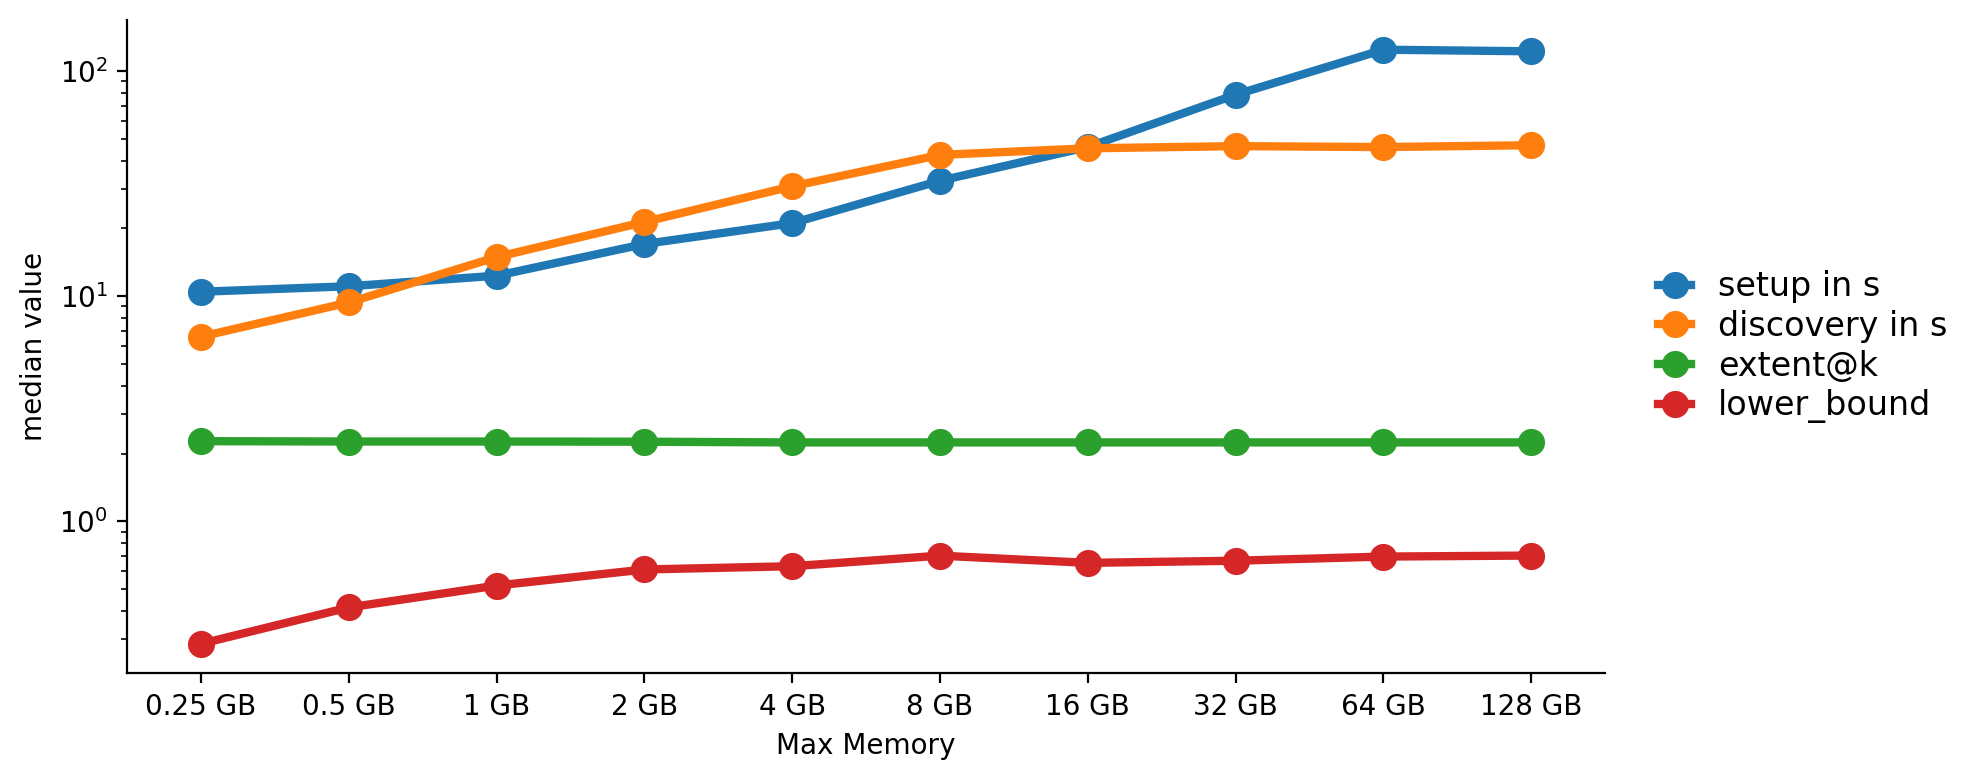

In [2]:
df_sub = df_all#[df_all["motif length"]== 4096].copy()


df_long = df_sub.melt(
    id_vars=["memory", "version"],
    value_vars=["setup in s", "discovery in s", "extent@k", "lower_bound"],  #  "extent@k - lower_bound", 
    var_name="Legend",
    value_name="median value"
)

fig, ax = plt.subplots(figsize=(10,4))

# lines (same aggregation)
sns.pointplot(
    y="median value",
    x="memory",
    hue="Legend",
    data=df_long,
    ax=ax,
    estimator="median",
    # dodge=True,
    order=custom_order,
    ci=None,
    linewidth=3
)

leg = ax.legend(
    # handles=handles,
    # labels=labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)


# ax.margins(x=0)
sns.despine()
plt.tight_layout()
# ax.set_title("Proper (log scale)")
ax.set_xlabel("Max Memory")
plt.yscale('log')


# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.savefig("images/pointplot_ablation.pdf", bbox_inches='tight')
plt.show()

pt = df_sub.pivot_table(
    index="memory",
    values=["setup in s", "discovery in s", "extent@k", "lower_bound"],
    aggfunc=["median", "mean"]
).sort_values(
    by="memory",
    key=lambda x: x.str.extract(r'(\d+)').astype(int)[0]
)


styled = pt.style.apply(highlight_col_min, axis=0).format("{:.1f}")
display(styled)

11.35954500525

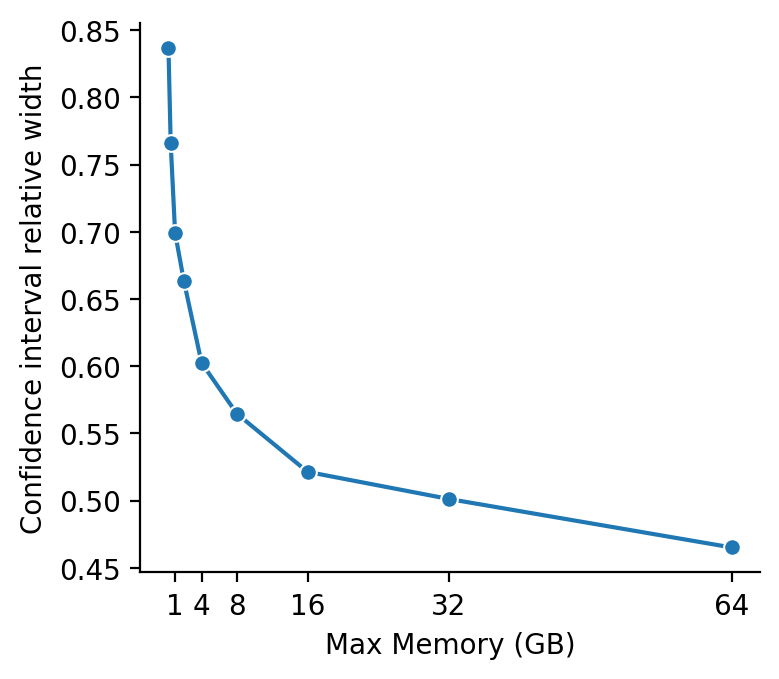

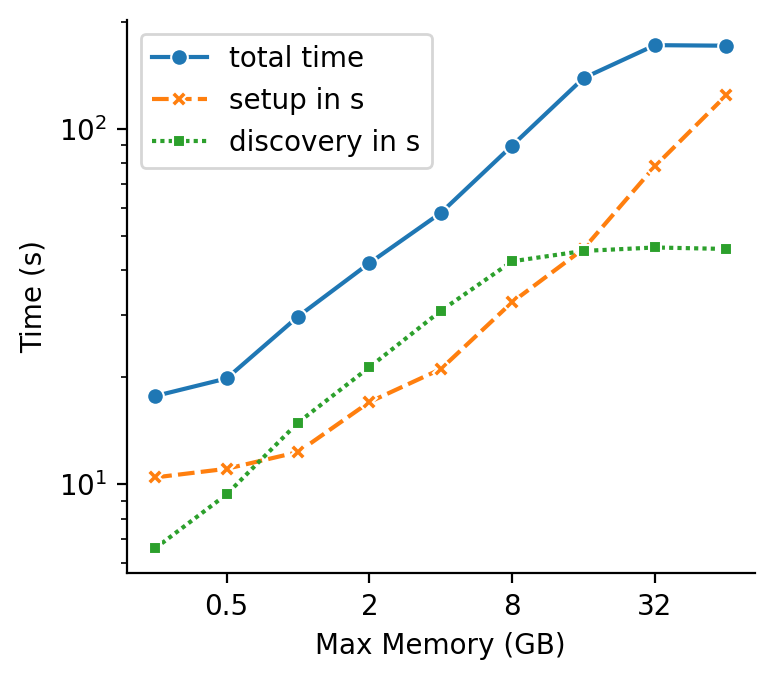

In [3]:
df_sub = df_all.copy()#[df_all["motif length"]== 4096].copy()
df_sub["ci-width"] = df_sub["extent@k"] - df_sub["lower_bound"]
df_sub["ci-width"] = np.maximum(df_sub["ci-width"], 0)
df_sub["ci-rel-width"] = df_sub["ci-width"] / df_sub["extent@k"]
df_sub["memory"] = df_sub["memory"].str.replace(" GB", "").astype(np.float64)
df_sub = df_sub[df_sub["memory"] <= 64]
df_sub["total time"] = df_sub["setup in s"] + df_sub["discovery in s"]
df_sub["normalized time"] = df_sub["total time"] / df_sub["length"]
df_sub["normalized memory"] = df_sub["memory"] / df_sub["length"]
# display(df_sub)
# display(df_sub[["setup in s", "discovery in s", "extent@k", "lower_bound", "ci-width", "ci-rel-width"]])
display(df_sub["total time"].max() / 60)

df_long = df_sub.melt(
    id_vars=["memory", "version", "motif length"],
    # value_vars=["setup in s", "discovery in s", "extent@k", "lower_bound", "ci-width", "ci-rel-width"],  #  "extent@k - lower_bound", 
    value_vars=["normalized time", "total time", "setup in s", "discovery in s", "extent@k", "lower_bound", "ci-width", "ci-rel-width"],
    # value_vars=["ci-rel-width"],
    var_name="Legend",
    value_name="median value"
)
df_plot1 = df_long[df_long["Legend"] == "ci-rel-width"]

figsize=(4,3.5)

fig, ax = plt.subplots(figsize=figsize)
g = sns.lineplot(
    y="median value",
    x="memory",
    hue="Legend",
    data=df_plot1,
    ax=ax,
    estimator="median",
    style="Legend",
    # dodge=True,
    # order=custom_order,
    ci=None,
    legend=False,
    markers=True,
    # linewidth=3
)

sns.despine()
# ax.set_xscale("log", base=2)
plt.tight_layout()
ax.set_xlabel("Max Memory (GB)")
ax.set_ylabel("Confidence interval relative width")
ax.set_xticks([1, 4, 8, 16, 32, 64])
plt.savefig("images/pointplot_ablation_interval_width.pdf", bbox_inches='tight')
plt.show()

df_plot2 = df_long[df_long["Legend"].isin(["total time", "setup in s", "discovery in s"])]

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    y="median value",
    x="memory",
    hue="Legend",
    style="Legend",
    data=df_plot2,
    ax=ax,
    estimator="median",
    markers=True,
    # dodge=True,
    # order=custom_order,
    ci=None,
    legend=True,
    # linewidth=3
)
sns.despine()
plt.tight_layout()
ax.set_xlabel("Max Memory (GB)")
ax.set_ylabel("Time (s)")
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(smart_fmt)
plt.legend(title="")
plt.savefig("images/pointplot_ablation_time.pdf", bbox_inches='tight')
plt.show()

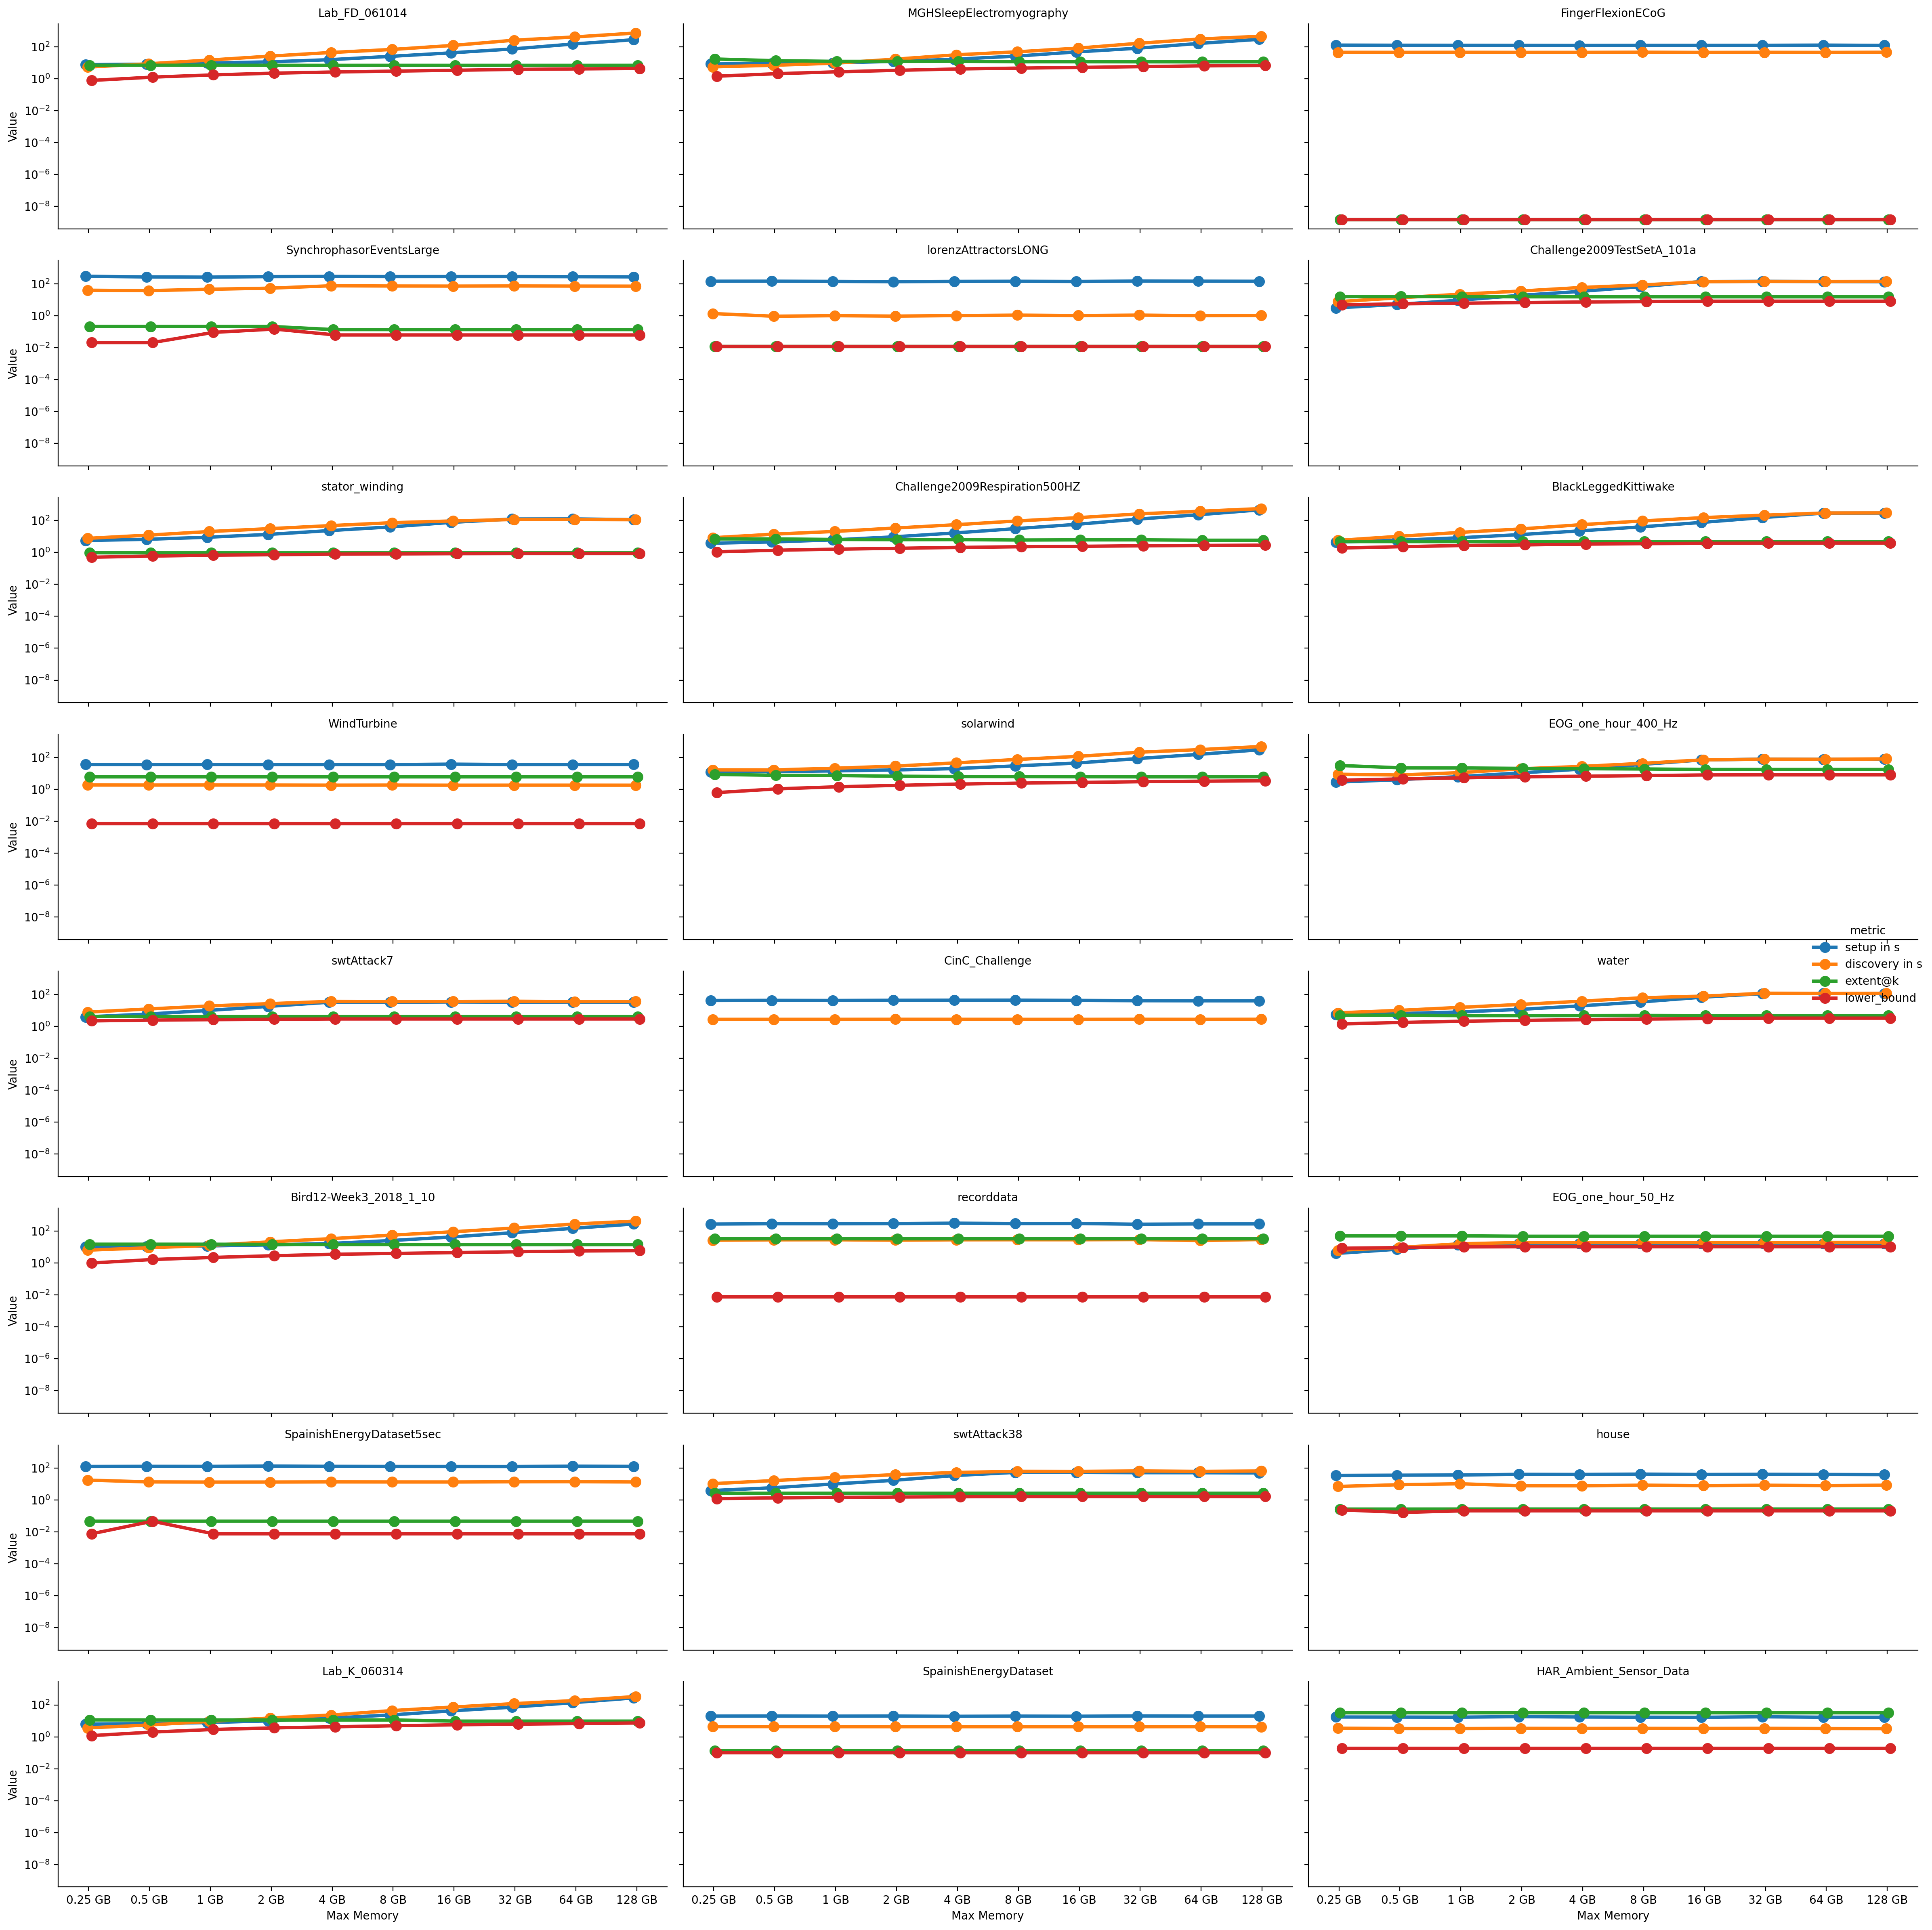

In [4]:

df_long2 = df_all[df_all["motif length"]==2048].melt(
    id_vars=["memory", "version", "dataset"],
    value_vars=["setup in s", "discovery in s", "extent@k", "lower_bound"],
    var_name="metric",
    value_name="value"
)

g = sns.catplot(
    kind="point",
    data=df_long2,
    x="memory",
    y="value",
    hue="metric",
    col="dataset",
    order=custom_order,
    estimator="median",
    errorbar=None,
    dodge=True,
    join=True,
    linewidth=3,
    col_wrap=3,
    height=3,
    aspect=2.5
)

g.set_axis_labels("Max Memory", "Value")
g.set_titles("{col_name}")

for ax in g.axes.flat:
   ax.set_yscale("log")

sns.despine()
g.figure.tight_layout()
g.figure.savefig("images/ablation_single.pdf", bbox_inches="tight")
plt.show()

In [5]:
df_long2 = df_all.melt(
    id_vars=["memory", "version", "dataset", "motif length"],
    value_vars=["setup in s", "discovery in s", "extent@k", "lower_bound"],
    var_name="metric",
    value_name="value"
)

# df_long.to_json("raw.json")
# df_long2.to_csv("raw_long.csv")
# df_all.to_csv("raw_wide.csv")